<a href="https://colab.research.google.com/github/aspurser84-dot/BIFX546-project/blob/main/notebooks/Final_BIFX546_Project_Graham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title: COVID-19 Variant tracking over time and location

Author: Amanda Graham

Course: BIFX 546 — Machine Learning for Bioinformatics, Spring 2026

Instructor: Dr. Sarangan (Ravi) Ravichandran

Date: 3/18/26

Dataset name: COVID-19 Variant Data

Source/URL: https://www.kaggle.com/datasets/nidzsharma/covid-19-variant-data

Project goal: This notebook analyzes a COVID-19 dataset to determine the variant circulation over time and location.

The below code changes the working directory so the data can be properly saved in Colab.

In [5]:
import os

# Show current working directory
print("Current directory:", os.getcwd())

# Move up one directory
os.chdir("..")

Current directory: /content


The below code imports the dataset from Kagglehub repository.

In [6]:
#Imports the dataset from Kagglehub repository and
#places the dataset in kaggle/input/ folder
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nidzsharma/covid-19-variant-data")

# Verify the actual data file is present, if not force re-download
csv_file = os.path.join(path, "covid19_variant.csv")

if not os.path.exists(csv_file):
  path = kagglehub.dataset_download("nidzsharma/covid-19-variant-data", force_download=True)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid-19-variant-data' dataset.
Path to dataset files: /kaggle/input/covid-19-variant-data


The below code converts the downloaded csv file to a pandas dataframe. Then a quick summary for the following variables; specimens, percentage, specimens 7 day average, and percentage 7 day average, calculates count, average, stand deviation, minimum, quantiles, and the maximum.

This is important since we can see the number of specimens collected and percentage of specimens collected does not match the specimens 7 day average or percentage 7 day average. The specimens 7 day average and percentage 7 day average have missing values that will need to be calculated.

In [7]:
#converts csv file to pandas dataframe
import pandas as pd

#quick summary of dataset
df = pd.read_csv(csv_file)
df.describe()

,specimens,percentage,specimens_7d_avg,percentage_7d_avg
count,7790.000000,7790.000000,7730.000000,7730.000000
mean,177.596919,20.000004,178.622731,20.000000
std,485.649656,37.925758,449.876303,37.927537
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.142857,0.013672
75%,28.000000,7.380000,27.857143,7.414083
max,5802.000000,100.000000,3295.000000,100.000000


The below code provides value counts for the number of variants.

This is important and shows there is also a total count being calculated. This will need to be removed when comparing individual variants.

In [8]:
#Determine the number of variants
#pd.value_counts(df["variant_name"])
pd.Series(df["variant_name"]).value_counts()

,count
variant_name,
Alpha,779
Lambda,779
Other,779
Epsilon,779
Omicron,779
Beta,779
Total,779
Delta,779
Mu,779


The below code calculates summary statistics median, average and standard deviation for each variant. Here we can already see there are two variants that have a higher presence in the data. Delta and Omicron.

We can also confirm the Total variant is the combined value for all variants and this will need to be removed when comparing the different variants.

In [9]:
#summary stats median, mean and standard deviation by variant type
df.groupby("variant_name")["specimens"].agg(["median", "mean", "std"])

,median,mean,std
variant_name,,,
Alpha,0.0,21.079589,48.532144
Beta,0.0,0.218228,0.868546
Delta,0.0,310.150193,654.710835
Epsilon,0.0,31.997433,98.848317
Gamma,0.0,4.747112,10.588784
Lambda,0.0,0.227214,0.855034
Mu,0.0,1.471117,5.580458
Omicron,241.0,491.812580,706.144161
Other,5.0,26.281130,55.751669


The below code determines if there are any NA values.

We can see the specimens 7 day average and percentage 7 day average do have missing values. These will need to be calculated and filled in.

In [10]:
#Determine if there are any NA values
df.isna().sum()
#Since the NA values are in 7day avg no need to remove these rows without 7 day averages

,0
date,0
area,0
area_type,0
variant_name,0
specimens,0
percentage,0
specimens_7d_avg,60
percentage_7d_avg,60


The below code calculates the rolling 7 day average.

In [11]:
# Calculate 7-day rolling average
#specimens_7d_avg
data = df['specimens'].tolist()
series = pd.Series(data)

moving_avg_specimens = series.rolling(window=7).mean()

#percentage_7d_avg
data = df['percentage'].tolist()
series = pd.Series(data)

moving_avg_percentage = series.rolling(window=7).mean()

The below code filles in the NA values with the calculated rolling 7 day average.

However the first 6 days cannot calculate a 7 day average and these must be filled in with a values of zero.

In [12]:
#Instead we want to fill in N/A values with 7 day average

df['specimens_7d_avg'] = moving_avg_specimens
print(df)

df['percentage_7d_avg'] = moving_avg_percentage
print(df)


            date        area area_type variant_name  specimens  percentage  \
0     01-01-2021  California     State        Alpha          1        1.69   
1     01-01-2021  California     State       Lambda          0        0.00   
2     01-01-2021  California     State        Other         29       49.15   
3     01-01-2021  California     State      Epsilon         28       47.46   
4     01-01-2021  California     State      Omicron          1        1.69   
...          ...         ...       ...          ...        ...         ...   
7785  18-02-2023  California     State       Lambda          0        0.00   
7786  18-02-2023  California     State         Beta          0        0.00   
7787  18-02-2023  California     State      Omicron         36       97.30   
7788  18-02-2023  California     State      Epsilon          0        0.00   
7789  18-02-2023  California     State        Other          1        2.70   

      specimens_7d_avg  percentage_7d_avg  
0                  

The below code filles in the first 6 days rolling average with zero since we cannot calculate a 7 day average in the first 6 days.

In [13]:
#replaced first 6 values with 0 since we can't calculate a 7 day average
df['specimens_7d_avg'] = df['specimens_7d_avg'].fillna(0)
df['percentage_7d_avg'] = df['percentage_7d_avg'].fillna(0)

This code confirms all NA values are filled in.

In [14]:
#Verify NA values were filled in
df.isna().sum()

,0
date,0
area,0
area_type,0
variant_name,0
specimens,0
percentage,0
specimens_7d_avg,0
percentage_7d_avg,0


The below code removes all rows with Total as the variant name. This is redundant information and not meaningful.

In [15]:
#Need to remove all rows with "Total" in variant_name
value_to_remove = 'Total'

# Remove rows where 'variant_name' equals "Total"
df2 = df[df['variant_name'] != value_to_remove]
df2

,date,area,area_type,variant_name,specimens,percentage,specimens_7d_avg,percentage_7d_avg
0,01-01-2021,California,State,Alpha,1,1.69,0.000000,0.000000
1,01-01-2021,California,State,Lambda,0,0.00,0.000000,0.000000
2,01-01-2021,California,State,Other,29,49.15,0.000000,0.000000
3,01-01-2021,California,State,Epsilon,28,47.46,0.000000,0.000000
4,01-01-2021,California,State,Omicron,1,1.69,0.000000,0.000000
...,...,...,...,...,...,...,...,...
7785,18-02-2023,California,State,Lambda,0,0.00,5.285714,14.285714
7786,18-02-2023,California,State,Beta,0,0.00,5.285714,14.285714
7787,18-02-2023,California,State,Omicron,36,97.30,10.428571,28.185714
7788,18-02-2023,California,State,Epsilon,0,0.00,10.428571,28.185714


The below code determines what data type each variable is. We can see date is an object but this is incorrect we need to change this to a date data type.

In [16]:
df2.dtypes

,0
date,object
area,object
area_type,object
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


The below code changes the date variable to a date time data type.

This will allow us to properly graph the data in seaborn.

In [17]:
df2['date'] = pd.to_datetime(df2['date'], format='%d-%m-%Y')
df2.dtypes

/tmp/ipykernel_30235/1411909734.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['date'] = pd.to_datetime(df2['date'], format='%d-%m-%Y')


,0
date,datetime64[ns]
area,object
area_type,object
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


In [18]:
df2

,date,area,area_type,variant_name,specimens,percentage,specimens_7d_avg,percentage_7d_avg
0,2021-01-01,California,State,Alpha,1,1.69,0.000000,0.000000
1,2021-01-01,California,State,Lambda,0,0.00,0.000000,0.000000
2,2021-01-01,California,State,Other,29,49.15,0.000000,0.000000
3,2021-01-01,California,State,Epsilon,28,47.46,0.000000,0.000000
4,2021-01-01,California,State,Omicron,1,1.69,0.000000,0.000000
...,...,...,...,...,...,...,...,...
7785,2023-02-18,California,State,Lambda,0,0.00,5.285714,14.285714
7786,2023-02-18,California,State,Beta,0,0.00,5.285714,14.285714
7787,2023-02-18,California,State,Omicron,36,97.30,10.428571,28.185714
7788,2023-02-18,California,State,Epsilon,0,0.00,10.428571,28.185714


In [19]:
rate_change = df2.groupby('variant_name', as_index=False)['specimens'].diff()
df3 = df2.copy()
df3['rate_change'] = rate_change
df3


,date,area,area_type,variant_name,specimens,percentage,specimens_7d_avg,percentage_7d_avg,rate_change
0,2021-01-01,California,State,Alpha,1,1.69,0.000000,0.000000,NaN
1,2021-01-01,California,State,Lambda,0,0.00,0.000000,0.000000,NaN
2,2021-01-01,California,State,Other,29,49.15,0.000000,0.000000,NaN
3,2021-01-01,California,State,Epsilon,28,47.46,0.000000,0.000000,NaN
4,2021-01-01,California,State,Omicron,1,1.69,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...
7785,2023-02-18,California,State,Lambda,0,0.00,5.285714,14.285714,0.0
7786,2023-02-18,California,State,Beta,0,0.00,5.285714,14.285714,0.0
7787,2023-02-18,California,State,Omicron,36,97.30,10.428571,28.185714,-2.0
7788,2023-02-18,California,State,Epsilon,0,0.00,10.428571,28.185714,0.0


In [75]:
# File path (can include folders)
file_path = "output/data.csv"

try:
    # Ensure the directory exists
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    # Export DataFrame to CSV
    df3.to_csv(file_path, index=False, encoding="utf-8")

    print(f"DataFrame successfully exported to '{file_path}'")
except PermissionError:
    print("Error: Permission denied. Please check file permissions.")
except FileNotFoundError:
    print("Error: Invalid file path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrame successfully exported to 'output/data.csv'


The below code creates a box plot for the number of specimens collected per variant.

Here we can see there are two variants with a higher number of specimens present, Delta and Omicron.

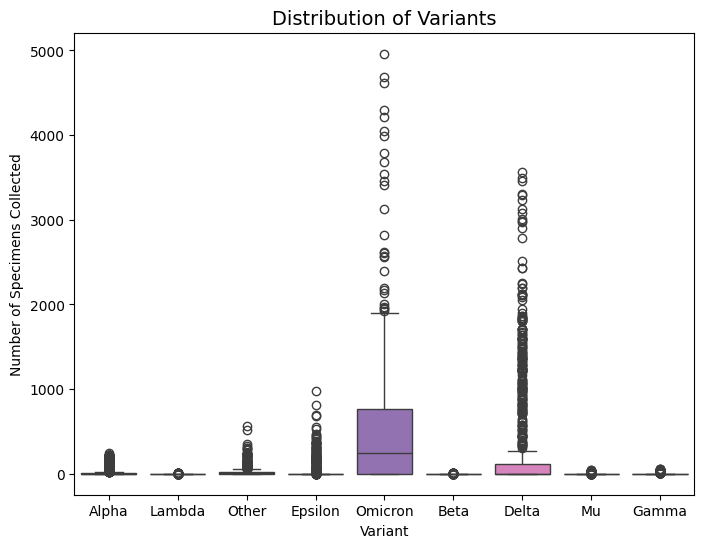

In [20]:
#Boxplot of number of specimen collected per variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df3,
    x="variant_name",
    y="specimens",
    hue="variant_name",   # Color by category
    palette="tab10",    # Color palette
    legend=False
)

# Add labels and title
plt.title("Distribution of Variants", fontsize=14)
plt.xlabel("Variant")
plt.ylabel("Number of Specimens Collected")

# Display plot
plt.show()

The code below graphs the number of specimens collected over time by variant. We can see the variant Delta starts about 07/2021 and is the main variant present until about 01/2022. Then both variants are present for a short time until the variant Omicron is the main variant until about 01/2023. Most of the other variants are present in low abundance.

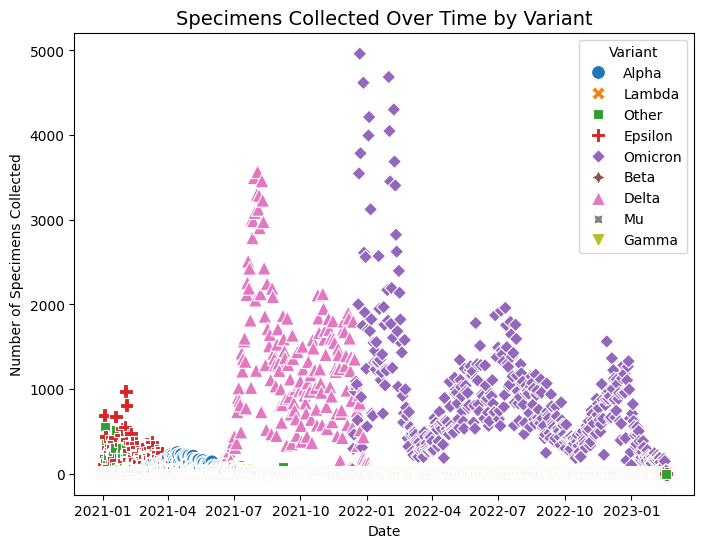

In [21]:
#XY scatter plot specimens collected over time by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df3,
    x="date",
    y="specimens",
    hue="variant_name",   # Color by category
    style="variant_name", # Different marker styles
    s=100,            # Marker size
    palette="tab10"    # Color palette
)

#plt.xticks(ticks=[0, 1, 2], labels=["2021", "2022", "2023"])

# Add labels and title
plt.title("Specimens Collected Over Time by Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Specimens Collected")
plt.legend(title="Variant")

# Display plot
plt.show()

The below code graphs the percentage of variants over time by variant.

This graph better shows the low abundance variants as a mixed population between 01/2021 through 07/2021. Between 01/2021 and 04/2021 we can see Epsilon and Other variant being the predominant variants present. Then between 04/2021 and 07/2021 we can see Alpha is the predominant variant present with the other variants still present in low abundance. Then we can see as Delta decreases in predominance Omicron increases and becomes the predominant variant present.

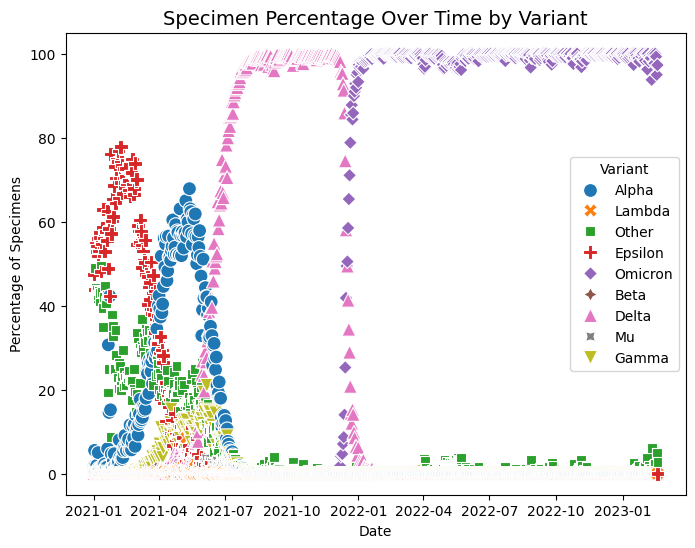

In [22]:
#XY scatter plot specimens collected over time by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df3,
    x="date",
    y="percentage",
    hue="variant_name",   # Color by category
    style="variant_name", # Different marker styles
    s=100,            # Marker size
    palette="tab10"    # Color palette
)

# Add labels and title
plt.title("Specimen Percentage Over Time by Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Percentage of Specimens")
plt.legend(title="Variant")

# Display plot
plt.show()

/tmp/ipykernel_30235/672558807.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Variant")


<Figure size 800x600 with 0 Axes>

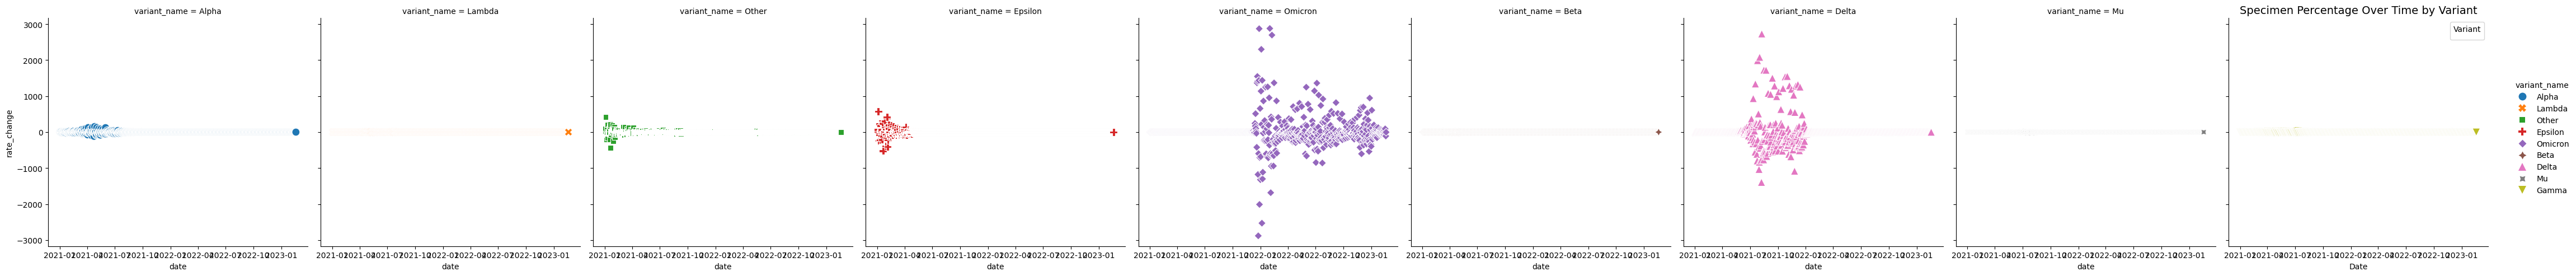

In [24]:
#XY scatter plot specimens collected over time by variant
###Needs work
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.relplot(
    data= df3,
    x="date",
    y="rate_change",
    col="variant_name",   # Color by category
    hue="variant_name",   # Color by category
    style="variant_name", # Different marker styles
    s=100,            # Marker size
    palette="tab10"    # Color palette
)

# Add labels and title
plt.title("Specimen Percentage Over Time by Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Percentage of Specimens")
plt.legend(title="Variant")

# Display plot
plt.show()

# Closing Progress:

##Results:
During the COVID-19 pandemic it was unknown if variants were present in equal abundance and circulating at the same time. This dataset provides insight on the predominant variant over time. It shows while there are some instances of multiple variants circulating, for the most part one variant becomes the predominant variant for a short period of time. Then as that variant starts to decrease we can see another variant increase and become the predominant variant.

##Challenges:
Uploading the data from the Kagglehub repository to work on Colab was the most challenging as this required additional code to set the correct working directory in Colab. Another challenge was having proper x labels for the seaborn plots. It was discovered the data type was an object and seaborn could not properly automate tick marks. In order to do this, additional code was created to use to_datetime and convert the Date variable into a proper date time data type. Further, I originally graphed the boxplot using matplot to demonstrate using an alternative graphing method but found seaborn is more user friendly, easily graphed the same data and was more appealing.

##Future Steps:
Create a model that can predict whether a variant will be dominant (above a threshold percentage) given its 7-day average and other features.
Requires the data to be separated into a training and validation dataset.
The training dataset would be used to train the model, and the validation dataset would be used to validate the model. Simple Logistic Regression or decision tree would work well for this classification.